# Data Exploration and Preparation — SAML-D
**Kaan Gogcay | AML Research**

This notebook explores the SAML-D dataset and iteratively develops the feature set used by both the XGBoost and DQN modelling notebooks.

<h2>Contents</h2>

- [1. Data Split](#1-data-split)
- [2. Data Exploration](#2-data-exploration)
    - [2.1 Class Imbalance](#21-class-imbalance)
    - [2.2 Available Features](#22-available-features)
- [3. XGBoost — Raw Features](#3-xgboost--raw-features)
    - [3.1 Class Weights](#31-class-weights)
    - [3.2 Training](#32-training)
    - [3.3 Evaluation — Raw Features](#33-evaluation--raw-features)
- [4. Feature Engineering](#4-feature-engineering)
    - [4.1 Fan_Out — After Feature Engineering](#41-fan_out--after-feature-engineering)
- [5. XGBoost — Feature Engineered](#5-xgboost--feature-engineered)
    - [5.1 Evaluation — Feature Engineered](#51-evaluation--feature-engineered)
- [6. Feature Engineering — Pair History](#6-feature-engineering--pair-history)
- [7. XGBoost — Feature Engineered with Pair History](#7-xgboost--feature-engineered-with-pair-history)
    - [7.1 Evaluation — Feature Engineered with Pair History](#71-evaluation--feature-engineered-with-pair-history)
        - [7.1.1 The Lower Spectrum](#711-the-lower-spectrum)
- [8. Conclusion](#8-conclusion)
- [9. Discussion](#9-discussion)
- [10. References](#10-references)


---

# 1. Data Split

The dataset is split into train, validation and test sets before any exploration or feature engineering takes place. Splitting first ensures that exploration is performed on training data only, preventing any possibility of data leakage into the modelling phase.

Since the dataset is temporal, it is split chronologically rather than randomly. In a real AML system, a model always scores transactions using only past information. A random split would allow the model to train on transactions from after the test period, constituting data leakage.

Traditional cross-validation is not possible, since the dataset is temporal. However, a variation of cross-validation, walk-forward validation, can be applied. This is a strategy where the dataset is split in folds, keeping the temporal aspect of the dataset.

| Fold | Train | Validation |
|---|---|---|
| 1 | A | B |
| 2 | A, B | C |
| 3 | A, B, C | D |
| 4 | A, B, C, D | E |

<br>

> *Training on B, C, D, E and then validating on A would result in data leakage, since E is the latest data available in this example*

Given the dataset size of 9.5 million transactions, training multiple models across folds would be computationally expensive, especially for the DQN. A fixed chronological 70/15/15 split is used instead, consistent with the experimental setup of [Oztas et al. (2023)](#10-references).

| Split | Ratio | Purpose |
|---|---|---|
| Train | 70% | Model training |
| Validation | 15% | Hyperparameter tuning |
| Test | 15% | Final evaluation only |


In [2]:
# [1a]
import pandas as pd
import numpy as np
import os

# Load data
df = pd.read_csv('../dataset/SAML-D.csv')
print(f'Dataset shape: {df.shape}')
print(f'Laundering rate: {df["Is_laundering"].mean() * 100:.4f}%')

# Sort chronologically
df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df = df.sort_values('datetime').reset_index(drop=True)

# Chronological 70/15/15 split — BEFORE feature engineering
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = df.iloc[:train_end].copy()
val_raw   = df.iloc[train_end:val_end].copy()
test_raw  = df.iloc[val_end:].copy()

print(f'\nSplit sizes — Train: {len(train_raw):,} | Val: {len(val_raw):,} | Test: {len(test_raw):,}')

Dataset shape: (9504852, 12)
Laundering rate: 0.1039%

Split sizes — Train: 6,653,396 | Val: 1,425,728 | Test: 1,425,728


---

# 2. Data Exploration

## 2.1 Class Imbalance

The dataset is extremely imbalanced, with only 0.1039% of all transactions being laundering (Codeblock 2.1a). After splitting chronologically, the laundering rate is consistent across all three sets: 0.1017% (train), 0.0990% (validation), and 0.1190% (test), confirming the split is representative (Codeblock 2.1b).

Verifying the laundering rate per split is a necessity. If the test set contained almost no laundering cases, the final evaluation would be meaningless regardless of model performance.

The test set will not be examined again until final evaluation.

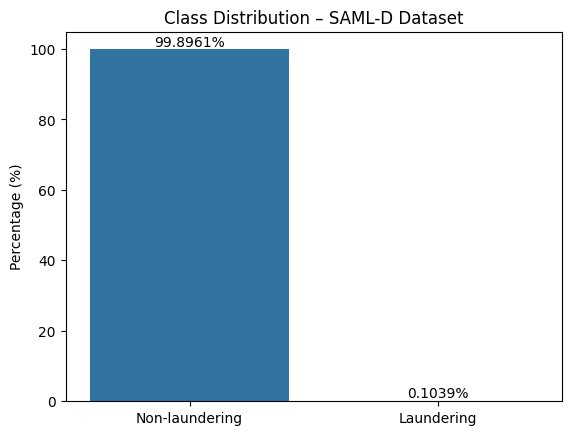

In [3]:
# [2.1a]
from matplotlib import pyplot as plt
import seaborn as sns

rates = df['Is_laundering'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(
    x=['Non-laundering', 'Laundering'],
    y=rates.values
)

# Add centered labels
for patch, value in zip(ax.patches, rates.values):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    ax.text(
        x,
        y + 0.02,
        f'{value:.4f}%',
        ha='center',
        va='bottom'
    )

plt.ylabel('Percentage (%)')
plt.title('Class Distribution – SAML-D Dataset')

plt.show()

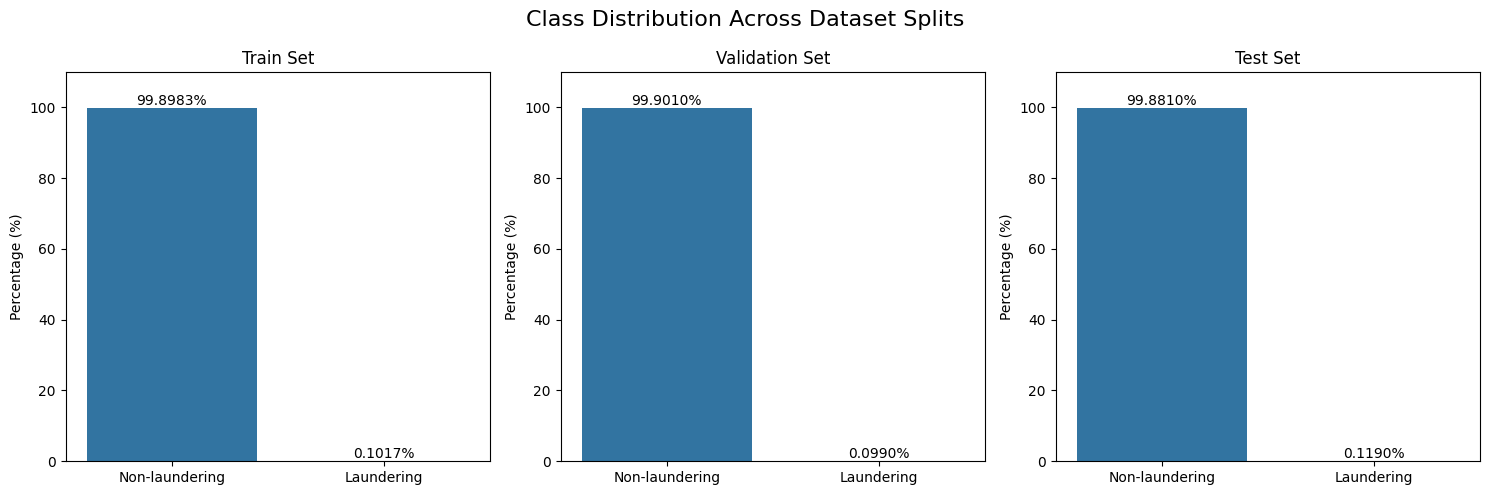

In [4]:
# [2.1b]
from matplotlib import pyplot as plt
import seaborn as sns

# Store splits
splits = {
    'Train': train_raw,
    'Validation': val_raw,
    'Test': test_raw
}

# Create 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, split_df) in zip(axes, splits.items()):

    # Calculate percentages
    rates = (
        split_df['Is_laundering']
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    # Plot
    sns.barplot(
        x=['Non-laundering', 'Laundering'],
        y=rates.values,
        ax=ax
    )

    # Add centered labels
    for patch, value in zip(ax.patches, rates.values):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        ax.text(
            x,
            y + 0.02,
            f'{value:.4f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(f'{name} Set')
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, max(rates.values) * 1.1)

# Overall title
fig.suptitle('Class Distribution Across Dataset Splits', fontsize=16)

plt.tight_layout()
plt.show()

## 2.2 Available Features
The SAML-D dataset contains 12 raw features. A `datetime` field is added manually by combining `Date` and `Time` for chronological sorting. Note that `Date`, `Time`, and `datetime` are used only for sorting and will be dropped before modelling. These raw features allow for a large scale of feature engineering. To ensure the feature engineering will help the model improve, a model without feature engineering will be trained first.

| Feature | Definition | Example Value |
|-|-|-|
| `Time` | Time of transaction | 10:35:19 |
| `Date` | Date of transaction | 2022-10-07 |
| `Sender_account` | ID of the account of the sender | 8724731955 |
| `Receiver_account` | ID of the account of the receiver | 2769355426 |
| `Amount` | Transaction amount | 1459.15 |
| `Payment_currency` | Currency of the sender | UK pounds |
| `Received_currency` | Currency of the receiver | UK pounds |
| `Sender_bank_location` | Bank country of the sender | UK |
| `Receiver_bank_location` | Bank country of the receiver | UK |
| `Payment_type` | Payment method | Cash Deposit |
| `Is_laundering` | Indicates whether the transaction is laundering (1) or normal (0) | 0 |
| `Laundering_type` | The type of laundering linked to the transaction | Normal_Cash_Deposits | 
| `datetime` | feature added for chronological split | 2022-10-07 10:35:19 |

`Payment_type` and `Laundering_type` are categorical and not self-explanatory and therefore require further explanation.

**Payment types (7 total):**

| Payment_type | Definition |
|-|-|
| Cash Deposit | Depositing physical cash into a bank account (for example at an ATM) |
| Cross-border | A transfer sent internationally across country borders |
| Cheque | A written paper instruction ordering a bank to pay a specified amount from one account to another |
| ACH | Automated Clearing House - an electronic batch payment system used for direct debits and bank transfers |
| Credit card | A payment made using a credit card |
| Debit card | A payment made using a debit card |
| Cash Withdrawal | Withdrawing physical cash from a bank account (for example at an ATM) |

**Transaction typologies (28 total, 11 normal and 17 suspicious)**

| Laundering_type | Suspicious | Definition |
|---|---|---|
| Normal_Cash_Deposits | No | A normal cash deposit into a bank account |
| Normal_Fan_Out | No | One account sending transactions to many different receivers, normal behaviour such as a business paying suppliers |
| Normal_Small_Fan_Out | No | One account sending small-amount transactions to many different receivers, normal behaviour such as splitting a bill |
| Normal_Fan_In | No | One account receiving transactions from many different senders, normal behaviour such as a business collecting customer payments |
| Normal_Group | No | An account that regularly transacts with a fixed group of accounts |
| Normal_Cash_Withdrawal | No | A normal cash withdrawal from a bank account |
| Normal_Periodical | No | An account making regular periodic transactions, normal behaviour such as monthly rent or subscription payments |
| Normal_Foward | No | An account receiving money and forwarding it to another account, normal behaviour such as passing on a reimbursement |
| Normal_Mutual | No | Two accounts that regularly send money back and forth to each other, normal behaviour such as two friends splitting costs |
| Normal_Plus_Mutual | No | A Normal_Group pattern extended with mutual transactions between the main account and its group members |
| Normal_single_large | No | A single large transaction that is normal in context, such as a house purchase or large business invoice |
| Smurfing | Yes | Breaking a large amount into many small transactions across multiple accounts to avoid detection thresholds, placement stage |
| Structuring | Yes | Deliberately keeping transactions just below reporting thresholds to avoid triggering regulatory scrutiny, placement stage |
| Cash_Withdrawal | Yes | Suspicious low-value cash withdrawals used to facilitate crimes such as forced servitude |
| Behavioural_Change_1 | Yes | An account that deviates from its Normal_Group pattern by suddenly transacting with new unknown accounts |
| Behavioural_Change_2 | Yes | An account that deviates from its Normal_Group pattern by suddenly transacting with new accounts in high-risk locations |
| Layered_Fan_In | Yes | A multi-layer Fan_In where funds pass through intermediate accounts before aggregating into a final destination, layering stage |
| Layered_Fan_Out | Yes | A multi-layer Fan_Out where funds pass through intermediate accounts before being scattered to final destinations, layering stage |
| Scatter-Gather | Yes | Funds are first scattered from one account to many, then regathered into a single destination account |
| Cycle | Yes | Money moves in a circular chain across multiple accounts, eventually returning to the originating account |
| Fan_In | Yes | Many accounts rapidly sending similar amounts to one central account, suspicious aggregation of laundered funds |
| Stacked Bipartite | Yes | Multiple layered bipartite networks stacked on top of each other to add complexity and obscure the money trail |
| Over-Invoicing | Yes | Inflating the value of goods or services in cross-border transactions to move money internationally under a legitimate cover |
| Deposit-Send | Yes | An account deposits cash and rapidly sends it onwards to another account, often below reporting thresholds and to high-risk countries |
| Single_large | Yes | A single unusually large transaction that stands out significantly from the account's normal transaction history |
| Bipartite | Yes | A fixed set of sender accounts transacting exclusively with a fixed set of receiver accounts, creating an isolated suspicious subnetwork |
| Gather-Scatter | Yes | Funds are first gathered from many sources into one account, then scattered to many destinations, combining Fan_In and Fan_Out |
| Fan_Out | Yes | One account rapidly sending money to many different receivers simultaneously, suspicious dispersal of laundered funds |

---

# 3. XGBoost — Raw Features

Before engineering any features, an XGBoost model is trained on the 12 raw SAML-D features. This establishes a baseline and reveals which laundering patterns the raw features alone cannot capture, directly motivating the feature engineering steps that follow.

In [5]:
# [3a]
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    classification_report,
)
import matplotlib.pyplot as plt


# Splits are already available from the Data Split section above

In [6]:
# [3b]
# =============================================================================
# 2. PREPARE FEATURES
# Drop: target and label-leaking column (Laundering_type kept in CSVs for dashboard)
# =============================================================================
DROP_COLS = ["Is_laundering", "Laundering_type", "Date", "Time", "datetime"]

def prepare(split_df):
    X = split_df.drop(columns=DROP_COLS)
    y = split_df["Is_laundering"]
    return X, y

X_train_raw, y_train_raw = prepare(train_raw)
X_val_raw,   y_val_raw   = prepare(val_raw)
X_test_raw,  y_test_raw  = prepare(test_raw)

# Convert object columns to category dtype (XGBoost native categorical support)
cat_cols_raw = X_train_raw.select_dtypes("object").columns.tolist()
for col in cat_cols_raw:
    X_train_raw[col] = X_train_raw[col].astype("category")
    X_val_raw[col]   = X_val_raw[col].astype("category")
    X_test_raw[col]  = X_test_raw[col].astype("category")

print(f"\nFeatures: {X_train_raw.columns.tolist()}")
print(f"Categorical features: {cat_cols_raw}")


Features: ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
Categorical features: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']


## 3.1 Class Weights

The training set contains approximately 982 normal transactions for every 1 laundering transaction (Codeblock 3.1a). Without correction, XGBoost will learn that predicting Normal for everything produces a very low loss because it is right 99.9% of the time, and effectively ignore the laundering class entirely.

`scale_pos_weight = neg / pos` tells XGBoost to treat each misclassified laundering transaction as if it were 982 misclassified normal transactions, forcing the model to take the minority class seriously during training.

In [7]:
# [3.1a]
# =============================================================================
# 3. CLASS IMBALANCE WEIGHT
# =============================================================================
neg = (y_train_raw == 0).sum()
pos = (y_train_raw == 1).sum()
scale_pos_weight = neg / pos

print(f"\nClass balance — Neg: {neg:,} | Pos: {pos:,} | scale_pos_weight: {scale_pos_weight:.1f}")


Class balance — Neg: 6,646,632 | Pos: 6,764 | scale_pos_weight: 982.6


## 3.2 Training

In [8]:
# [3.2a]
# =============================================================================
# 4. TRAIN MODEL
# =============================================================================
model_raw = xgb.XGBClassifier(
    tree_method="hist",        # Required: 9.5M rows, hist is the only practical choice
    enable_categorical=True,   # Required: native categorical support for your features
    scale_pos_weight=neg/pos,  # Required: 0.104% imbalance, mathematically justified
    eval_metric="aucpr",       # Required: matches your primary evaluation metric
    early_stopping_rounds=50,  # Required: needs validation set, prevents overfitting
    random_state=42,           # Required: reproducibility safeguard
    n_jobs=-1,                 # Practical: use all cores
    device="cuda"              # Practical: GPU training for speed (if available)
)

model_raw.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_val_raw, y_val_raw)],
    verbose=50,
)

print(f"\nBest iteration: {model_raw.best_iteration}")

[0]	validation_0-aucpr:0.06712
[50]	validation_0-aucpr:0.07139
[99]	validation_0-aucpr:0.07649

Best iteration: 95


## 3.3 Evaluation — Raw Features

The area under the precision-recall curve is 0.0770 (Codeblock 3.3a). Below is a per-pattern analysis of what patterns are successfully captured and which are not (Codeblock 3.3c). The pattern detected least is `Fan_Out` with a catch rate of 18.39%. Feature engineering will be applied to address this.

In [9]:
# [3.3a]
# =============================================================================
# 5. EVALUATE — PRIMARY METRIC: AUPRC
# =============================================================================
def evaluate(model_raw, X, y, split_name):
    y_proba = model_raw.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f"\n{'='*50}")
    print(f"{split_name} AUPRC: {auprc:.4f}")
    return y_proba, auprc

y_val_proba_raw,  val_auprc_raw  = evaluate(model_raw, X_val_raw,  y_val_raw,  "Validation")

y_val_pred_raw = (y_val_proba_raw >= 0.5).astype(int)

c:\Users\thezo\anaconda3\envs\art2\lib\site-packages\xgboost\core.py:158: UserWarning: [12:22:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



Validation AUPRC: 0.0770


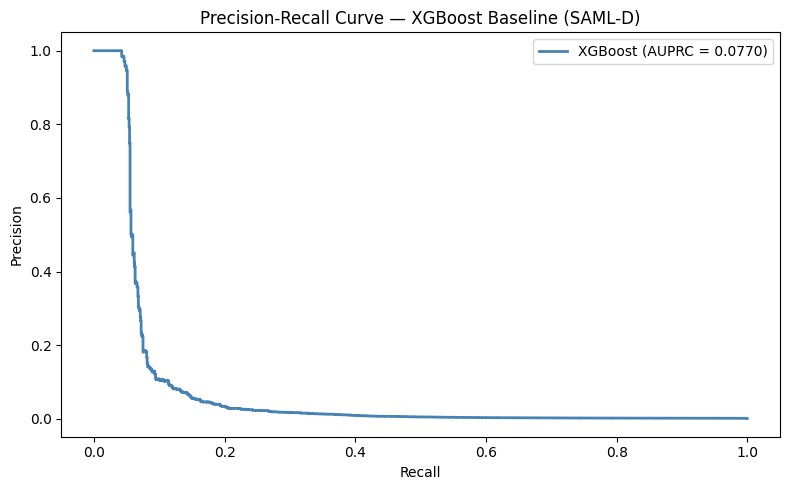

Saved: pr_curve_it1_raw_val.png


In [10]:
# [3.3b]
# =============================================================================
# 6. PRECISION-RECALL CURVE PLOT
# =============================================================================
precision_raw, recall_raw, thresholds_raw = precision_recall_curve(y_val_raw, y_val_proba_raw)

plt.figure(figsize=(8, 5))
plt.plot(recall_raw, precision_raw, color="steelblue", lw=2,
         label=f"XGBoost (AUPRC = {val_auprc_raw:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline (SAML-D)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_it1_raw_val.png", dpi=150)
plt.show()
print("Saved: pr_curve_it1_raw_val.png")

     Laundering_type  total  caught  missed  catch_rate
             Fan_Out   87.0    16.0    71.0   18.390805
      Layered_Fan_In   92.0    17.0    75.0   18.478261
     Layered_Fan_Out   53.0    11.0    42.0   20.754717
      Scatter-Gather   43.0     9.0    34.0   20.930233
      Gather-Scatter   43.0    10.0    33.0   23.255814
              Fan_In   68.0    17.0    51.0   25.000000
Behavioural_Change_1   71.0    20.0    51.0   28.169014
               Cycle   66.0    19.0    47.0   28.787879
           Bipartite   37.0    11.0    26.0   29.729730
   Stacked Bipartite   93.0    29.0    64.0   31.182796
         Structuring  194.0    95.0    99.0   48.969072
Behavioural_Change_2   86.0    44.0    42.0   51.162791
      Over-Invoicing   14.0     9.0     5.0   64.285714
        Single_large   31.0    21.0    10.0   67.741935
        Deposit-Send  134.0    94.0    40.0   70.149254
     Cash_Withdrawal  173.0   165.0     8.0   95.375723
            Smurfing  127.0   122.0     5.0   96

C:\Users\thezo\AppData\Local\Temp\ipykernel_10496\2860321961.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_results = laundering_val_raw.groupby('Laundering_type').apply(


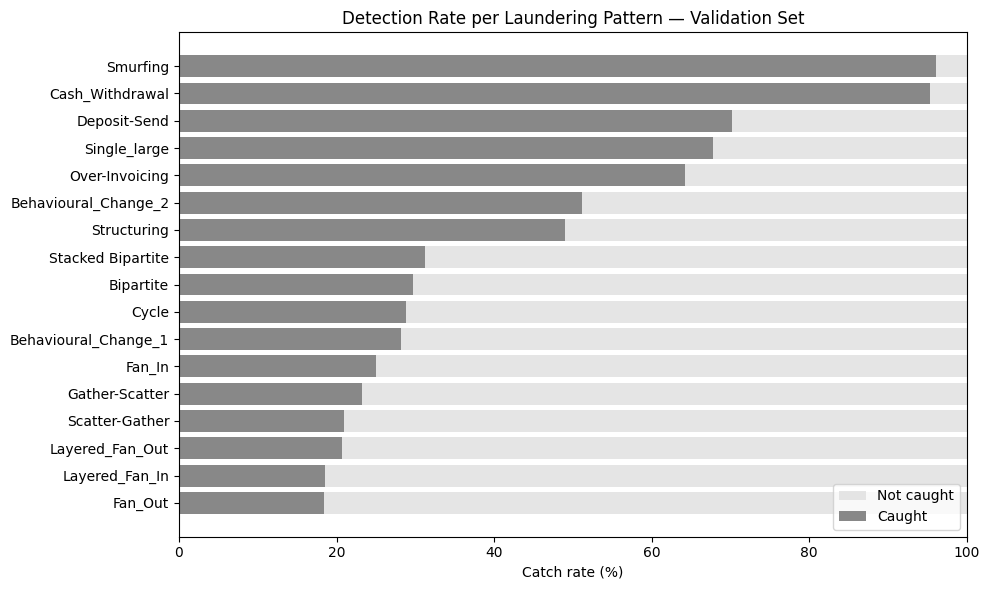

In [11]:
# [3.3c]
# Per-pattern detection analysis on validation set
THRESHOLD = 0.5

val_analysis_raw = val_raw.copy()
val_analysis_raw['predicted_score'] = y_val_proba_raw
val_analysis_raw['predicted_label'] = (y_val_proba_raw >= THRESHOLD).astype(int)

# Only look at actual laundering transactions
laundering_val_raw = val_analysis_raw[val_analysis_raw['Is_laundering'] == 1]

# Per pattern: how many were caught?
pattern_results = laundering_val_raw.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index().sort_values('catch_rate', ascending=True)

print(pattern_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

# Red background bar (full 100% — not caught)
ax.barh(pattern_results['Laundering_type'], 100,
        color="#dddddd", alpha=0.75, label='Not caught')

# Blue foreground bar (caught)
ax.barh(pattern_results['Laundering_type'], pattern_results['catch_rate'],
        color='#888888', label='Caught')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 100)
ax.set_title('Detection Rate per Laundering Pattern — Validation Set')
ax.legend()
plt.tight_layout()
plt.savefig('pattern_detection_it1_raw_val.png', dpi=150)
plt.show()

# 4. Feature Engineering

Comparing raw `Fan_Out` and `Normal_Fan_Out` transactions side by side (Code block 4a), the two groups are nearly indistinguishable from the raw features alone. This explains why the model fails to detect this pattern. To address this, additional features are derived from the raw data to give the model more context about the accounts behind each transaction.

For each bank account in the training set, a statistical profile is built from its transaction history, inspired by [Harris et al. (2021)](#10-references) who demonstrated
that adding account-level summary statistics derived from transaction history improves money laundering detection performance.

*Before: only the raw transaction fields:*

| Date | Time | Sender_account | Receiver_account | Amount | Payment_type |
|---|---|---|---|---|---|
| 2022-03-14 | 09:32:11 | 1 | 67 | 5,450 | Credit card |
| 2022-03-14 | 11:15:44 | 1 | 203 | 6,100 | Credit card |

*After: sender's training history is looked up by account ID and appended as new columns: **(only 5 engineered features are added to this example for readability sake)***

| Date | Time | Sender_account | Receiver_account | Amount | Payment_type | sender_tx_count | sender_amount_mean | sender_unique_receivers | fan_out_ratio | is_cross_border |
|---|---|---|---|---|---|---|---|---|---|---|
| 2022-03-14 | 09:32:11 | 1 | 67 | 5,450 | Credit card | 847 | 1,243 | 312 | 0.37 | 1 |
| 2022-03-14 | 11:15:44 | 1 | 203 | 6,100 | Credit card | 847 | 1,243 | 312 | 0.37 | 1 |

Notice that both transactions share the same engineered feature values because they come from the same sender account. The profile reflects the account's entire training history, not the individual transaction.

The following engineered features are derived from the training set only and attached to every transaction by matching on account ID. Accounts not seen in training receive a value of `0` for all engineered features, reflecting the assumption that no prior history is known.

In [12]:
# [4a]
# Print 5 Normal_Fan_Out and 5 Fan_Out transactions from training set
for pattern in ['Normal_Fan_Out', 'Fan_Out']:
    print(f'\n{"="*60}')
    print(f'{pattern} — 5 example transactions')
    print(f'{"="*60}')
    sample = train_raw[train_raw['Laundering_type'] == pattern].head(5)
    print(sample.to_string(index=False))


Normal_Fan_Out — 5 example transactions
    Time       Date  Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type            datetime
10:35:20 2022-10-07      1491989064        8401255335  6019.64        UK pounds            Dirham                   UK                    UAE Cross-border              0  Normal_Fan_Out 2022-10-07 10:35:20
10:35:26 2022-10-07      6116657264         656192169  4738.45        UK pounds         UK pounds                   UK                     UK       Cheque              0  Normal_Fan_Out 2022-10-07 10:35:26
10:35:29 2022-10-07      7421451752        2755709071  5883.87     Indian rupee         UK pounds                   UK                     UK  Credit card              0  Normal_Fan_Out 2022-10-07 10:35:29
10:35:46 2022-10-07      3709430533        9172843471  5274.76        UK pounds         UK pounds                   UK                 

In [13]:
# [4b]
DROP_COLS = ['datetime', 'Date', 'Time']
train_raw = train_raw.drop(columns=DROP_COLS)
val_raw   = val_raw.drop(columns=DROP_COLS)
test_raw  = test_raw.drop(columns=DROP_COLS)

# Sender-level aggregates — computed on train only
sender_agg = train_raw.groupby('Sender_account').agg(
    sender_tx_count         =('Amount', 'count'),
    sender_amount_mean      =('Amount', 'mean'),
    sender_amount_std       =('Amount', 'std'),
    sender_amount_min       =('Amount', 'min'),
    sender_amount_max       =('Amount', 'max'),
    sender_unique_receivers =('Receiver_account', 'nunique'),
    sender_unique_currencies=('Payment_currency', 'nunique'),
    sender_unique_locations =('Receiver_bank_location', 'nunique'),
).reset_index()

# Receiver-level aggregates — computed on train only
receiver_agg = train_raw.groupby('Receiver_account').agg(
    receiver_tx_count         =('Amount', 'count'),
    receiver_amount_mean      =('Amount', 'mean'),
    receiver_amount_std       =('Amount', 'std'),
    receiver_unique_senders   =('Sender_account', 'nunique'),
    receiver_unique_currencies=('Received_currency', 'nunique'),
    receiver_unique_locations =('Sender_bank_location', 'nunique'),
).reset_index()

# Account duality sets — from training history only
train_sender_set   = set(train_raw['Sender_account'].unique())
train_receiver_set = set(train_raw['Receiver_account'].unique())

def add_features_base(split_df, sender_agg, receiver_agg, train_sender_set, train_receiver_set):
    df = split_df.copy()
    df = df.merge(sender_agg,   on='Sender_account',   how='left')
    df = df.merge(receiver_agg, on='Receiver_account', how='left')
    agg_cols = (
        list(sender_agg.columns.drop('Sender_account')) +
        list(receiver_agg.columns.drop('Receiver_account'))
    )
    df[agg_cols] = df[agg_cols].fillna(0)
    df['fan_out_ratio'] = df['sender_unique_receivers'] / df['sender_tx_count'].replace(0, 1)
    df['fan_in_ratio']  = df['receiver_unique_senders'] / df['receiver_tx_count'].replace(0, 1)
    df['is_cross_currency'] = (df['Payment_currency'] != df['Received_currency']).astype(int)
    df['is_cross_border']   = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)
    return df

train_engineered = add_features_base(train_raw, sender_agg, receiver_agg, train_sender_set, train_receiver_set)
val_engineered   = add_features_base(val_raw,   sender_agg, receiver_agg, train_sender_set, train_receiver_set)
test_engineered  = add_features_base(test_raw,  sender_agg, receiver_agg, train_sender_set, train_receiver_set)

print(f'Features after engineering: {train_engineered.shape[1]} columns')

Features after engineering: 28 columns


## 4.1 Fan_Out — After Feature Engineering

With the engineered features, differences between suspicious and normal Fan_Out transactions become visible (Codeblock 4.1a). Suspicious Fan_Out accounts tend to have a low `sender_tx_count`, meaning they are relatively new or low-activity accounts that suddenly send to many different receivers. Normal Fan_Out accounts, by contrast, tend to have established histories with higher transaction counts.

In [14]:
# [4.1a]
# Print 5 Normal_Fan_Out and 5 Fan_Out transactions from training set
for pattern in ['Normal_Fan_Out', 'Fan_Out']:
    print(f'\n{"="*60}')
    print(f'{pattern} — 5 example transactions')
    print(f'{"="*60}')
    sample = train_engineered[train_engineered['Laundering_type'] == pattern].head(5)
    print(sample.to_string(index=False))


Normal_Fan_Out — 5 example transactions
 Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border
     1491989064        8401255335  6019.64        UK pounds            Dirham                   UK                    UAE Cross-border              0  Normal_Fan_Out              368         6888.261141       28630.387620              10.37          539159.80                       46                         4                        6                 12           6021.031667            31.635744                   

---

# 5. XGBoost — Feature Engineered

A second XGBoost model is trained on the feature engineered dataset. Rather than analysing each pattern individually as done prior, the model is trained directly on the new set and the per-pattern catch rates are compared to the raw features baseline.

## 5.1 Training 

In [15]:
# [5.1a]
# Prepare feature engineered splits
DROP_COLS_FE = ['Is_laundering', 'Laundering_type']

X_train_eng, y_train_eng = train_engineered.drop(columns=DROP_COLS_FE), train_engineered['Is_laundering']
X_val_eng,   y_val_eng   = val_engineered.drop(columns=DROP_COLS_FE),   val_engineered['Is_laundering']
X_test_eng,  y_test_eng  = test_engineered.drop(columns=DROP_COLS_FE),  test_engineered['Is_laundering']

cat_cols_eng = X_train_eng.select_dtypes('object').columns.tolist()
for col in cat_cols_eng:
    X_train_eng[col] = X_train_eng[col].astype('category')
    X_val_eng[col]   = X_val_eng[col].astype('category')
    X_test_eng[col]  = X_test_eng[col].astype('category')

print(f'Features: {X_train_eng.columns.tolist()}')

# =============================================================================
# TRAIN MODEL 2 — Feature Engineered
# =============================================================================
model_engineered = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    device='cuda'
)

model_engineered.fit(
    X_train_eng, y_train_eng,
    eval_set=[(X_val_eng, y_val_eng)],
    verbose=50,
)

print(f'\nBest iteration: {model_engineered.best_iteration}')

Features: ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'sender_tx_count', 'sender_amount_mean', 'sender_amount_std', 'sender_amount_min', 'sender_amount_max', 'sender_unique_receivers', 'sender_unique_currencies', 'sender_unique_locations', 'receiver_tx_count', 'receiver_amount_mean', 'receiver_amount_std', 'receiver_unique_senders', 'receiver_unique_currencies', 'receiver_unique_locations', 'fan_out_ratio', 'fan_in_ratio', 'is_cross_currency', 'is_cross_border']
[0]	validation_0-aucpr:0.02498
[50]	validation_0-aucpr:0.76902
[84]	validation_0-aucpr:0.76824

Best iteration: 34


## 5.2 Evaluation

Almost all patterns are detected at a higher rate than in the raw features model (Codeblock 5.2c). However, `Fan_Out` remains on the lower end of the spectrum (Codeblock 5.2d). Detection rates on Smurfing and Over-Invoicing got slightly worse with a drop of 2% and 14% respectively.

Examining the missed Fan_Out cases, Codeblock 5.1e, reveals a consistent pattern: almost all missed transactions have `receiver_unique_senders` of 0 or 1, meaning the receiver has little to no transaction history in the training set. The model does not flag these because a receiver with almost no history looks identical to a normal account. Looking at the Normal_Fan_Out transactions confirms this, since their receivers also typically have low `receiver_unique_senders`.

To differentiate suspicious Fan_Out from normal fan-out behaviour, a new feature is needed. Suspicious Fan_Out transactions tend to originate from the same sender account sending to many new receivers (Codeblock 5.2e). Tracking how many times a specific sender-receiver pair has transacted before would provide this signal directly.

In [16]:
# [5.2a]
# =============================================================================
# 5. EVALUATE — PRIMARY METRIC: AUPRC
# =============================================================================
def evaluate(model_raw, X, y, split_name):
    y_proba = model_raw.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f"\n{'='*50}")
    print(f"{split_name} AUPRC: {auprc:.4f}")
    return y_proba, auprc

y_val_proba_eng, val_auprc_eng  = evaluate(model_engineered, X_val_eng,  y_val_eng,  "Validation")

y_val_pred_eng = (y_val_proba_eng >= 0.5).astype(int)
print("\nClassification report at 0.5 threshold (informational):")
print(classification_report(y_val_eng, y_val_pred_eng, target_names=["Normal", "Laundering"]))


Validation AUPRC: 0.7704

Classification report at 0.5 threshold (informational):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424316
  Laundering       0.37      0.77      0.50      1412

    accuracy                           1.00   1425728
   macro avg       0.69      0.88      0.75   1425728
weighted avg       1.00      1.00      1.00   1425728



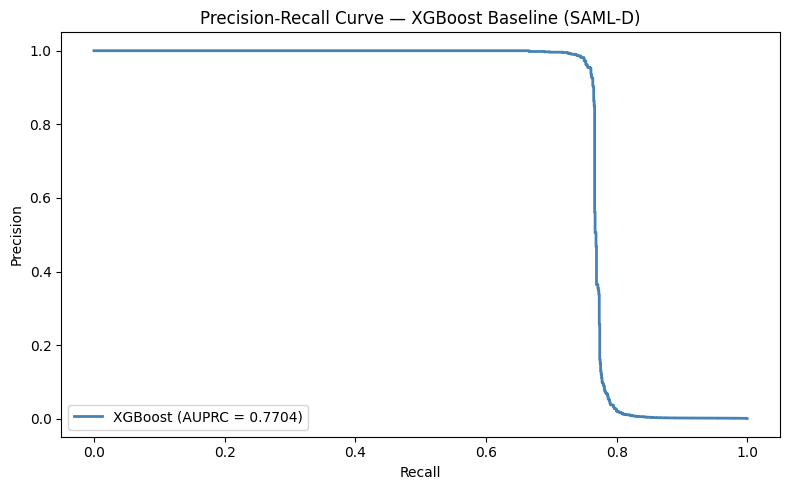

Saved: pr_curve_xgboost_2.png


In [17]:
# [5.2b]
# =============================================================================
# 6. PRECISION-RECALL CURVE PLOT
# =============================================================================
precision_eng, recall_eng, thresholds_eng = precision_recall_curve(y_val_eng, y_val_proba_eng)

plt.figure(figsize=(8, 5))
plt.plot(recall_eng, precision_eng, color="steelblue", lw=2,
         label=f"XGBoost (AUPRC = {val_auprc_eng:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline (SAML-D)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_it2_engineered_val.png", dpi=150)
plt.show()
print("Saved: pr_curve_xgboost_2.png")

C:\Users\thezo\AppData\Local\Temp\ipykernel_10496\3029793533.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_eng = laundering_val_eng.groupby('Laundering_type').apply(
C:\Users\thezo\AppData\Local\Temp\ipykernel_10496\3029793533.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_raw = laundering_val_raw.groupby('Laundering_type').apply(


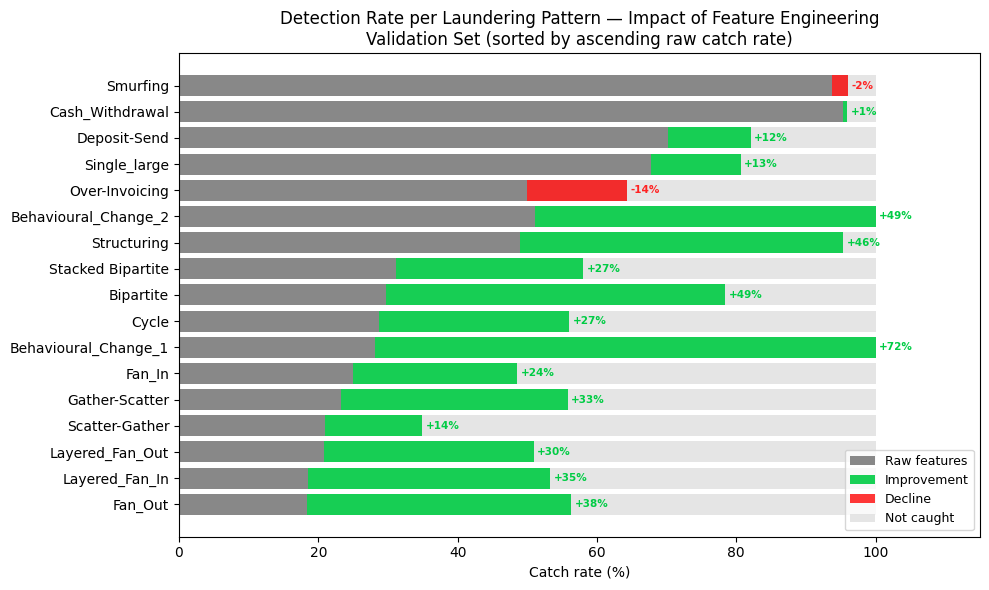

In [20]:
THRESHOLD = 0.5

val_analysis_eng = val_engineered.copy()
val_analysis_eng['predicted_score'] = y_val_proba_eng
val_analysis_eng['predicted_label'] = (y_val_proba_eng >= THRESHOLD).astype(int)

laundering_val_eng = val_analysis_eng[val_analysis_eng['Is_laundering'] == 1]

pattern_eng = laundering_val_eng.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index()

pattern_raw = laundering_val_raw.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index()

pattern_combined = pattern_eng.merge(
    pattern_raw, on='Laundering_type', suffixes=('_eng', '_raw')
).assign(improvement=lambda x: x['catch_rate_eng'] - x['catch_rate_raw'])\
 .sort_values('catch_rate_raw', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Red background (not caught)
ax.barh(pattern_combined['Laundering_type'], 100,
        color='#dddddd', alpha=0.75, label='Not caught')

# Blue base bar (raw catch rate)
ax.barh(pattern_combined['Laundering_type'], pattern_combined['catch_rate_raw'],
        color='#888888', label='Raw features')

# Green or red improvement bar on top
for _, row in pattern_combined.iterrows():
    improvement = row['catch_rate_eng'] - row['catch_rate_raw']
    color = '#00cc44' if improvement >= 0 else '#ff2222'
    ax.barh(row['Laundering_type'], improvement, 
            left=row['catch_rate_raw'], color=color, alpha=0.9)
    sign = '+' if improvement >= 0 else ''
    # Anchor text at the end of the engineered bar
    x_pos = max(row['catch_rate_raw'], row['catch_rate_eng']) + 0.5
    ax.text(x_pos, row['Laundering_type'],
            f"{sign}{improvement:.0f}%",
            va='center', fontsize=7.5, color=color, fontweight='bold')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 115)
ax.set_title('Detection Rate per Laundering Pattern — Impact of Feature Engineering\nValidation Set (sorted by ascending raw catch rate)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#888888', label='Raw features'),
    Patch(facecolor='#00cc44', alpha=0.9, label='Improvement'),
    Patch(facecolor='#ff2222', alpha=0.9, label='Decline'),
    Patch(facecolor='#dddddd', alpha=0.75, label='Not caught'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('pattern_detection_it1_vs_it2_val.png', dpi=150, bbox_inches='tight')
plt.show()

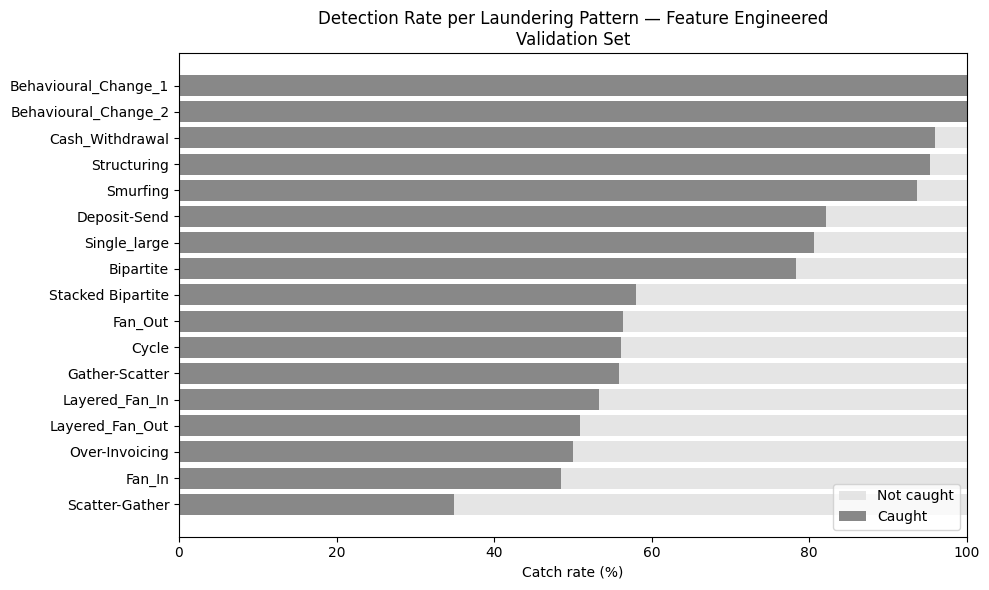

In [21]:
# [5.2d]
pattern_eng_sorted = pattern_eng.sort_values('catch_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(pattern_eng_sorted['Laundering_type'], 100,
        color="#dddddd", alpha=0.75, label='Not caught')

ax.barh(pattern_eng_sorted['Laundering_type'], pattern_eng_sorted['catch_rate'],
        color='#888888', label='Caught')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 100)
ax.set_title('Detection Rate per Laundering Pattern — Feature Engineered\nValidation Set')
ax.legend()
plt.tight_layout()
plt.savefig('pattern_detection_it2_engineered_val.png', dpi=150)
plt.show()

In [22]:
# [5.2e]
# Print Fan_Out transactions — suspicious and normal, caught and missed
n=10

fan_out_analysis = val_analysis_eng[val_analysis_eng['Laundering_type'] == 'Fan_Out']
normal_fan_out_analysis = val_analysis_eng[val_analysis_eng['Laundering_type'] == 'Normal_Fan_Out']

print(f'\n{"="*60}')
print('Fan_Out (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)')
print(f'{"="*60}')
print(fan_out_analysis[fan_out_analysis['predicted_label'] == 1].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Fan_Out (SUSPICIOUS) — predicted NORMAL (missed)')
print(f'{"="*60}')
print(fan_out_analysis[fan_out_analysis['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal_Fan_Out (NORMAL) — predicted NORMAL (correctly ignored)')
print(f'{"="*60}')
print(normal_fan_out_analysis[normal_fan_out_analysis['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal_Fan_Out (NORMAL) — predicted SUSPICIOUS (false positive)')
print(f'{"="*60}')
print(normal_fan_out_analysis[normal_fan_out_analysis['predicted_label'] == 1].head(n ).to_string(index=False))


Fan_Out (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)
 Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border  predicted_score  predicted_label
     9163385117        4418736003 12130.24        UK pounds         UK pounds                   UK                     UK   Debit card              1         Fan_Out            160.0         5213.660875        6610.233996             124.93           27490.75                     23.0                       2.0                      3.0              107.0     

---

# 6. Feature Engineering — Pair History

The previous model still misses Fan_Out transactions sent to receivers with little or no history. A new feature `pair_tx_count` is introduced, representing the number of times this specific sender-receiver pair has transacted together in the training set. A value of `0` indicates a completely new relationship, which is a direct signal for Fan_Out.

In [23]:
# [6a]
# Pair-level aggregate — computed on train only
# pair_tx_count = 0 means this sender-receiver pair has never transacted before in training
pair_agg = train_raw.groupby(['Sender_account', 'Receiver_account']).size().reset_index(name='pair_tx_count')

In [24]:
# [6b]
def add_features_with_pair(split_df, sender_agg, receiver_agg, pair_agg):
    df = split_df.copy()
    df = df.merge(sender_agg, on='Sender_account', how='left')
    df = df.merge(receiver_agg, on='Receiver_account', how='left')
    df = df.merge(pair_agg, on=['Sender_account', 'Receiver_account'], how='left')
    
    agg_cols = (
        list(sender_agg.columns.drop('Sender_account')) +
        list(receiver_agg.columns.drop('Receiver_account'))
    )
    df[agg_cols] = df[agg_cols].fillna(0)
    df['pair_tx_count'] = df['pair_tx_count'].fillna(0)  # 0 = never seen this pair before
    
    df['fan_out_ratio']     = df['sender_unique_receivers'] / df['sender_tx_count'].replace(0, 1)
    df['fan_in_ratio']      = df['receiver_unique_senders'] / df['receiver_tx_count'].replace(0, 1)
    df['is_cross_currency'] = (df['Payment_currency'] != df['Received_currency']).astype(int)
    df['is_cross_border']   = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)
    return df

train_engineered_pair = add_features_with_pair(train_raw, sender_agg, receiver_agg, pair_agg)
val_engineered_pair   = add_features_with_pair(val_raw,   sender_agg, receiver_agg, pair_agg)
test_engineered_pair  = add_features_with_pair(test_raw,  sender_agg, receiver_agg, pair_agg)

---
# 7. XGBoost — Feature Engineered with Pair History

A third model is trained on the feature set that includes `pair_tx_count`. The per-pattern catch rates are compared against the previous iteration.

## 7.1 Training

In [25]:
# [7.1a]
# Prepare feature engineered splits
DROP_COLS_FE = ['Is_laundering', 'Laundering_type']

X_train_pair, y_train_pair = train_engineered_pair.drop(columns=DROP_COLS_FE), train_engineered_pair['Is_laundering']
X_val_pair,   y_val_pair   = val_engineered_pair.drop(columns=DROP_COLS_FE),   val_engineered_pair['Is_laundering']
X_test_pair,  y_test_pair  = test_engineered_pair.drop(columns=DROP_COLS_FE),  test_engineered_pair['Is_laundering']

cat_cols_pair = X_train_pair.select_dtypes('object').columns.tolist()
for col in cat_cols_pair:
    X_train_pair[col] = X_train_pair[col].astype('category')
    X_val_pair[col]   = X_val_pair[col].astype('category')
    X_test_pair[col]  = X_test_pair[col].astype('category')

print(f'Features: {X_train_pair.columns.tolist()}')

# =============================================================================
# TRAIN MODEL 3 — Feature Engineered
# =============================================================================
model_pair = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    device='cuda'
)

model_pair.fit(
    X_train_pair, y_train_pair,
    eval_set=[(X_val_pair, y_val_pair)],
    verbose=50,
)

print(f'\nBest iteration: {model_pair.best_iteration}')

Features: ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'sender_tx_count', 'sender_amount_mean', 'sender_amount_std', 'sender_amount_min', 'sender_amount_max', 'sender_unique_receivers', 'sender_unique_currencies', 'sender_unique_locations', 'receiver_tx_count', 'receiver_amount_mean', 'receiver_amount_std', 'receiver_unique_senders', 'receiver_unique_currencies', 'receiver_unique_locations', 'pair_tx_count', 'fan_out_ratio', 'fan_in_ratio', 'is_cross_currency', 'is_cross_border']
[0]	validation_0-aucpr:0.78776
[50]	validation_0-aucpr:0.90826
[99]	validation_0-aucpr:0.90247

Best iteration: 63


## 7.2 Evaluation

All per-pattern detection rates are higher or equal compared to the previous iteration (Codeblock 7.2c). The targeted pattern `Fan_Out` improved by 31%, comparable patterns such as `Layered_Fan_Out`, `Fan_In` and `Layered_Fan_In` improved significantly by 38%, 35% and 19% respectively. Every other pattern detection rate improved or remained unchanged, confirming that adding `pair_tx_count` was beneficial across the board.

The lowest catch rates are `Scatter-Gather` (67.44%), `Layered_Fan_In` (71.74%) and `Cycle` (80.30%) (Codeblock 7.1d). These remaining gaps are attributed to the fundamental limitations of static account-level aggregates for patterns that require time-window or graph-based features.

In [26]:
# [7.2a]
# =============================================================================
# 5. EVALUATE — PRIMARY METRIC: AUPRC
# =============================================================================
def evaluate(model_raw, X, y, split_name):
    y_proba = model_raw.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f"\n{'='*50}")
    print(f"{split_name} AUPRC: {auprc:.4f}")
    return y_proba, auprc

y_val_proba_pair, val_auprc_pair  = evaluate(model_pair, X_val_pair,  y_val_pair,  "Validation")

y_val_pred_pair = (y_val_proba_pair >= 0.5).astype(int)
print("\nClassification report at 0.5 threshold (informational):")
print(classification_report(y_val_pair, y_val_pred_pair, target_names=["Normal", "Laundering"]))


Validation AUPRC: 0.9087

Classification report at 0.5 threshold (informational):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424316
  Laundering       0.40      0.91      0.55      1412

    accuracy                           1.00   1425728
   macro avg       0.70      0.95      0.78   1425728
weighted avg       1.00      1.00      1.00   1425728



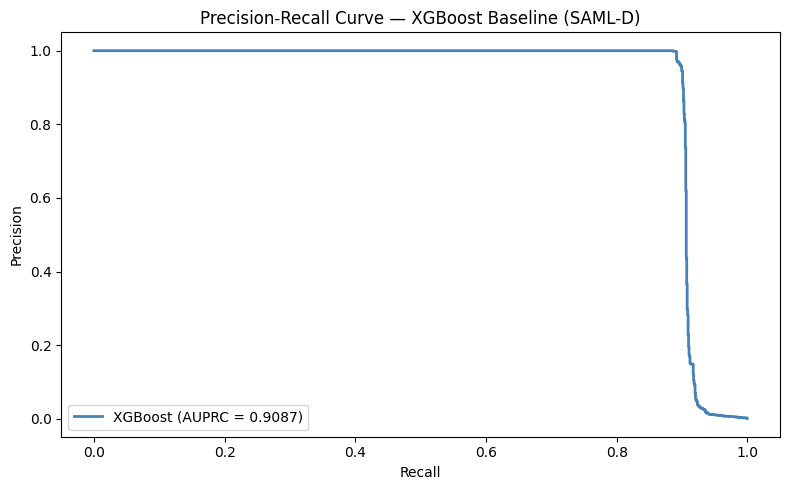

Saved: pr_curve_it3_pair_val.png


In [27]:
# [7.2b]
# =============================================================================
# 6. PRECISION-RECALL CURVE PLOT
# =============================================================================
precision_pair, recall_pair, thresholds_pair = precision_recall_curve(y_val_pair, y_val_proba_pair)

plt.figure(figsize=(8, 5))
plt.plot(recall_pair, precision_pair, color="steelblue", lw=2,
         label=f"XGBoost (AUPRC = {val_auprc_pair:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost Baseline (SAML-D)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve_it3_pair_val.png", dpi=150)
plt.show()
print("Saved: pr_curve_it3_pair_val.png")

C:\Users\thezo\AppData\Local\Temp\ipykernel_10496\891680878.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_pair = laundering_val_pair.groupby('Laundering_type').apply(


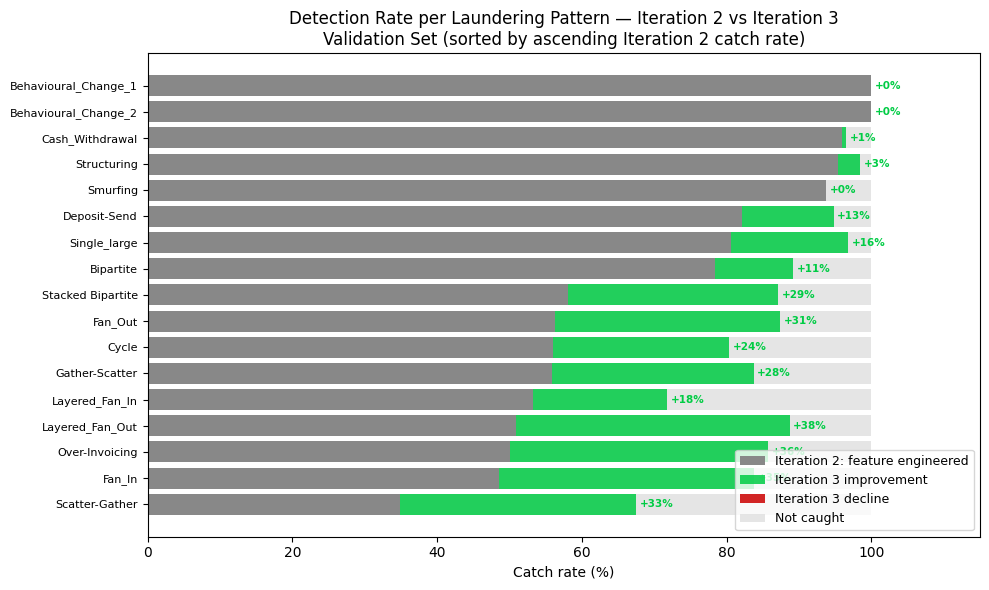

In [28]:
# [7.2c]
val_analysis_pair = val_engineered_pair.copy()
val_analysis_pair['predicted_score'] = y_val_proba_pair
val_analysis_pair['predicted_label'] = (y_val_proba_pair >= THRESHOLD).astype(int)

laundering_val_pair = val_analysis_pair[val_analysis_pair['Is_laundering'] == 1]

pattern_pair = laundering_val_pair.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index()

pattern_combined = pattern_pair.merge(
    pattern_eng[['Laundering_type', 'catch_rate']],
    on='Laundering_type', suffixes=('_pair', '_eng')
).sort_values('catch_rate_eng', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(pattern_combined))

# Background (not caught)
ax.barh(y_pos, 100, color='#dddddd', alpha=0.75, label='Not caught')

# Iteration 2 base bar
ax.barh(y_pos, pattern_combined['catch_rate_eng'],
        color='#888888', label='Iteration 2: feature engineered')

# Iteration 3 gain/loss on top of iteration 2
for i, (_, row) in enumerate(pattern_combined.iterrows()):
    imp = row['catch_rate_pair'] - row['catch_rate_eng']
    color = '#00cc44' if imp >= 0 else '#cc0000'
    ax.barh(i, imp, left=row['catch_rate_eng'], color=color, alpha=0.85)
    sign = '+' if imp >= 0 else ''
    ax.text(row['catch_rate_pair'] + 0.5, i,
            f"{sign}{imp:.0f}%",
            va='center', fontsize=7.5,
            color='#00cc44' if imp >= 0 else '#cc0000',
            fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(pattern_combined['Laundering_type'], fontsize=8)
ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 115)
ax.set_title('Detection Rate per Laundering Pattern — Iteration 2 vs Iteration 3\nValidation Set (sorted by ascending Iteration 2 catch rate)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#888888', label='Iteration 2: feature engineered'),
    Patch(facecolor='#00cc44', alpha=0.85, label='Iteration 3 improvement'),
    Patch(facecolor='#cc0000', alpha=0.85, label='Iteration 3 decline'),
    Patch(facecolor='#dddddd', alpha=0.75, label='Not caught'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('pattern_detection_it2_vs_it3_val.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\thezo\AppData\Local\Temp\ipykernel_10496\1664061761.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_results = laundering_val_pair.groupby('Laundering_type').apply(


     Laundering_type  total  caught  missed  catch_rate
      Scatter-Gather   43.0    29.0    14.0   67.441860
      Layered_Fan_In   92.0    66.0    26.0   71.739130
               Cycle   66.0    53.0    13.0   80.303030
      Gather-Scatter   43.0    36.0     7.0   83.720930
              Fan_In   68.0    57.0    11.0   83.823529
      Over-Invoicing   14.0    12.0     2.0   85.714286
   Stacked Bipartite   93.0    81.0    12.0   87.096774
             Fan_Out   87.0    76.0    11.0   87.356322
     Layered_Fan_Out   53.0    47.0     6.0   88.679245
           Bipartite   37.0    33.0     4.0   89.189189
            Smurfing  127.0   119.0     8.0   93.700787
        Deposit-Send  134.0   127.0     7.0   94.776119
     Cash_Withdrawal  173.0   167.0     6.0   96.531792
        Single_large   31.0    30.0     1.0   96.774194
         Structuring  194.0   191.0     3.0   98.453608
Behavioural_Change_2   86.0    86.0     0.0  100.000000
Behavioural_Change_1   71.0    71.0     0.0  100

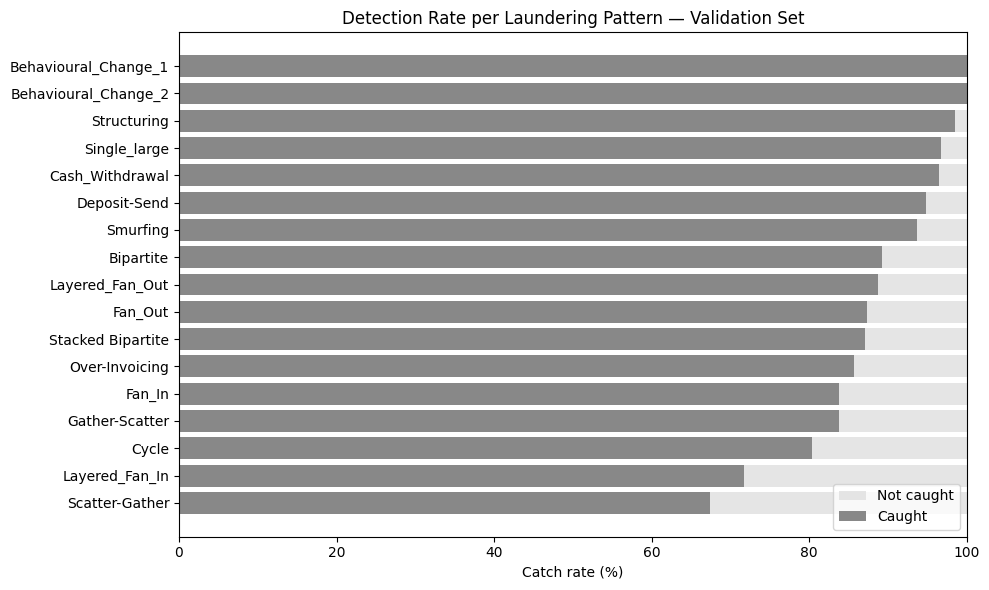

In [29]:
# [7.2d]
# Per-pattern detection analysis on validation set
THRESHOLD = 0.5

val_analysis_pair = val_engineered_pair.copy()
val_analysis_pair['predicted_score'] = y_val_proba_pair
val_analysis_pair['predicted_label'] = (y_val_proba_pair >= THRESHOLD).astype(int)

# Only look at actual laundering transactions
laundering_val_pair = val_analysis_pair[val_analysis_pair['Is_laundering'] == 1]

# Per pattern: how many were caught?
pattern_results = laundering_val_pair.groupby('Laundering_type').apply(
    lambda x: pd.Series({
        'total'     : len(x),
        'caught'    : (x['predicted_label'] == 1).sum(),
        'missed'    : (x['predicted_label'] == 0).sum(),
        'catch_rate': (x['predicted_label'] == 1).mean() * 100
    })
).reset_index().sort_values('catch_rate', ascending=True)

print(pattern_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

# Red background bar (full 100% — not caught)
ax.barh(pattern_results['Laundering_type'], 100,
        color="#dddddd", alpha=0.75, label='Not caught')

# Blue foreground bar (caught)
ax.barh(pattern_results['Laundering_type'], pattern_results['catch_rate'],
        color='#888888', label='Caught')

ax.set_xlabel('Catch rate (%)')
ax.set_xlim(0, 100)
ax.set_title('Detection Rate per Laundering Pattern — Validation Set')
ax.legend()
plt.tight_layout()
plt.savefig('pattern_detection_it3_pair_val.png', dpi=150)
plt.show()

### 7.2.1 The Lower Spectrum

The patterns with the lowest detection rates are `Scatter-Gather` (67.44%), `Layered_Fan_In` (71.74%) and `Cycle` (80.30%) (Codeblock 7.2d). What these patterns have in common is that they involve money moving across multiple accounts over time. This sequential, multi-hop movement cannot be captured with static account-level aggregates and is therefore out of scope for this feature set.

Code blocks 7.2.1a, 7.2.1b and 7.2.1c print for each pattern: correctly detected laundering transactions, missed laundering transactions, and normal transactions for comparison. Analysis of these outputs reveals no clear feature engineering opportunities. This is consistent with the nature of these patterns. `Scatter-Gather`, `Layered_Fan_In` and `Cycle` all require tracking money movement across multiple accounts over time, which cannot be captured by static transaction-level features regardless of how many are engineered.

In [30]:
# [7.2.1a] Scatter-Gather
# Print Scatter-Gather transactions — suspicious, caught and missed
n = 10

scatter_gather_analysis = val_analysis_pair[val_analysis_pair['Laundering_type'] == 'Scatter-Gather']
normal_comparison       = val_analysis_pair[val_analysis_pair['Is_laundering'] == 0]

print(f'\n{"="*60}')
print('Scatter-Gather (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)')
print(f'{"="*60}')
print(scatter_gather_analysis[scatter_gather_analysis['predicted_label'] == 1].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Scatter-Gather (SUSPICIOUS) — predicted NORMAL (missed)')
print(f'{"="*60}')
print(scatter_gather_analysis[scatter_gather_analysis['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal transactions — for comparison')
print(f'{"="*60}')
print(normal_comparison.head(n).to_string(index=False))


Scatter-Gather (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)
 Sender_account  Receiver_account   Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  pair_tx_count  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border  predicted_score  predicted_label
     9990989594        1171302146  7925.66        UK pounds         UK pounds                   UK                     UK  Credit card              1  Scatter-Gather            164.0         7790.850671        3545.401166              53.60           13414.97                     15.0                       4.0                      3.0  

In [31]:
# [7.2.1b] Layered_Fan_In
# Print Layered_Fan_In transactions — suspicious, caught and missed
n = 10

layered_fan_in_analysis = val_analysis_pair[val_analysis_pair['Laundering_type'] == 'Layered_Fan_In']
normal_comparison       = val_analysis_pair[val_analysis_pair['Is_laundering'] == 0]

print(f'\n{"="*60}')
print('Layered_Fan_In (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)')
print(f'{"="*60}')
print(layered_fan_in_analysis[layered_fan_in_analysis['predicted_label'] == 1].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Layered_Fan_In (SUSPICIOUS) — predicted NORMAL (missed)')
print(f'{"="*60}')
print(layered_fan_in_analysis[layered_fan_in_analysis['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal transactions — for comparison')
print(f'{"="*60}')
print(normal_comparison.head(n).to_string(index=False))


Layered_Fan_In (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)
 Sender_account  Receiver_account        Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  pair_tx_count  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border  predicted_score  predicted_label
     6158272176        4157434602  38105.137872        UK pounds         UK pounds                   UK                     UK   Debit card              1  Layered_Fan_In            152.0         5788.577961        5264.559657              39.54           22232.47                     16.0                       3.0                 

In [32]:
# [7.2.1c] Cycle
# Print Cycle transactions — suspicious, caught and missed
n = 10

cycle_analysis    = val_analysis_pair[val_analysis_pair['Laundering_type'] == 'Cycle']
normal_comparison = val_analysis_pair[val_analysis_pair['Is_laundering'] == 0]

print(f'\n{"="*60}')
print('Cycle (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)')
print(f'{"="*60}')
print(cycle_analysis[cycle_analysis['predicted_label'] == 1].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Cycle (SUSPICIOUS) — predicted NORMAL (missed)')
print(f'{"="*60}')
print(cycle_analysis[cycle_analysis['predicted_label'] == 0].head(n).to_string(index=False))

print(f'\n{"="*60}')
print('Normal transactions — for comparison')
print(f'{"="*60}')
print(normal_comparison.head(n).to_string(index=False))


Cycle (SUSPICIOUS) — predicted SUSPICIOUS (correctly caught)
 Sender_account  Receiver_account       Amount Payment_currency Received_currency Sender_bank_location Receiver_bank_location Payment_type  Is_laundering Laundering_type  sender_tx_count  sender_amount_mean  sender_amount_std  sender_amount_min  sender_amount_max  sender_unique_receivers  sender_unique_currencies  sender_unique_locations  receiver_tx_count  receiver_amount_mean  receiver_amount_std  receiver_unique_senders  receiver_unique_currencies  receiver_unique_locations  pair_tx_count  fan_out_ratio  fan_in_ratio  is_cross_currency  is_cross_border  predicted_score  predicted_label
     6145026715        8134515972 34919.350904        UK pounds         UK pounds                   UK                     UK       Cheque              1           Cycle            237.0         3300.492194        5701.053146              17.33           72237.20                     29.0                       2.0                      2.0   

---

# 8. Conclusion

The iterative feature engineering process is complete. Three rounds of engineering were performed on the same XGBoost model configuration, each motivated by empirical analysis of missed detections:

| Iteration | Feature Set | Val AUPRC |
|---|---|---|
| 1 - Raw features | 12 raw SAML-D features only | 0.0770 |
| 2 - Feature engineered | Raw + sender/receiver aggregates + fan ratios + cross-currency/border flags | 0.7704 |
| 3 - Pair history | Iteration 2 + `pair_tx_count` | 0.9087 |

The remaining gaps in `Scatter-Gather`, `Layered_Fan_In`, `Cycle`, and `Fan_In` are acknowledged limitations requiring time-window or graph-based features, which are outside the scope of this research. The final feature set is saved to disk and loaded by both the XGBoost and DQN modelling notebooks.

In [33]:
# [8a]
# Save final feature engineered splits to disk
# Both XGBoost and DQN notebooks load from these files
# Feature set: sender/receiver aggregates + pair_tx_count + fan ratios + cross-currency/border flags
os.makedirs('../dataset_FE_2', exist_ok=True)

train_engineered_pair.to_csv('../dataset_FE_2/train.csv', index=False)
val_engineered_pair.to_csv('../dataset_FE_2/val.csv',     index=False)
test_engineered_pair.to_csv('../dataset_FE_2/test.csv',   index=False)

print('Saved: dataset_FE_2/train.csv, dataset_FE_2/val.csv, dataset_FE_2/test.csv')
print(f'Train shape : {train_engineered_pair.shape}')
print(f'Val shape   : {val_engineered_pair.shape}')
print(f'Test shape  : {test_engineered_pair.shape}')
print(f'Features    : {[c for c in train_engineered_pair.columns if c not in ["Is_laundering", "Laundering_type"]]}')

Saved: dataset_FE_2/train.csv, dataset_FE_2/val.csv, dataset_FE_2/test.csv
Train shape : (6653396, 29)
Val shape   : (1425728, 29)
Test shape  : (1425728, 29)
Features    : ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'sender_tx_count', 'sender_amount_mean', 'sender_amount_std', 'sender_amount_min', 'sender_amount_max', 'sender_unique_receivers', 'sender_unique_currencies', 'sender_unique_locations', 'receiver_tx_count', 'receiver_amount_mean', 'receiver_amount_std', 'receiver_unique_senders', 'receiver_unique_currencies', 'receiver_unique_locations', 'pair_tx_count', 'fan_out_ratio', 'fan_in_ratio', 'is_cross_currency', 'is_cross_border']


---

# 9. Discussion

## Feature Value Ambiguity

Accounts not seen in training receive a value of `0` for all engineered features. For most features this is unambiguous, any account present in the training data has made at least one transaction, so `sender_tx_count = 0` can only mean the account was unseen. However, two features have genuine ambiguity:

- `sender_amount_std = 0` — could indicate either an unseen account or an account that made only one transaction and therefore has no variation in amounts.
- `receiver_amount_std = 0` — same ambiguity on the receiver side.

## Static vs Live Features

All engineered features are computed from the training set and frozen at that point. In real deployment, account profiles would ideally update with each new transaction, a live-updating `receiver_unique_senders` would increment as new senders send to a receiver, directly capturing the Fan_In pattern as it unfolds. Implementing live-updating features without introducing leakage is a non-trivial engineering challenge and is left out of scope.

# 10. References

###### Harris, D. A., Pyndiura, K. L., Sturrock, S. L., and Christensen, R. A. (2021). Using real-world transaction data to identify money laundering: Leveraging traditional regression and machine learning techniques. STEM Fellowship Journal, 7(1):1–11. https://doi.org/10.17975/sfj-2021-006.

###### Oztas, B., Cetinkaya, D., Adedoyin, F., Budka, M., Dogan, H., and Aksu, G. (2023). Enhancing anti-money laundering: Development of a synthetic transaction monitoring dataset. In 2023 IEEE International Conference on e-Business Engineering (ICEBE), pages 47–54. https://doi.org/10.1109/ICEBE59045.2023.00028.